# Median House Value with one-hidden layer neural networks (Classification)
### Keras
Code by [D. Manrique](https://orcid.org/0000-0002-0792-4156)

## Import libraries



In [3]:
# Tensorflow and tf.keras
import tensorflow as tf
from tensorflow import keras
print("Tensorflow version:",tf.__version__)
print("Keras version:",keras.__version__)

# Helper libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

Tensorflow version: 2.17.1
Keras version: 3.13.2


### Callbacks

In [5]:
from tensorflow.keras.callbacks import Callback
from tqdm import tqdm

class TqdmProgressCallback(Callback):
    def __init__(self, epochs, verbose=0):
        super(TqdmProgressCallback, self).__init__()
        self.epochs = epochs
        self.verbose = verbose
        
    def on_train_begin(self, logs=None):
        self.epoch_bar = tqdm(total=self.epochs, desc='Epochs', position=0)
       
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_bar.update(1)
        
    def on_train_end(self, logs=None):
        self.epoch_bar.close()

In [6]:
class StopWhenValLossBelow(Callback):
    def __init__(self, threshold):
        super().__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_loss')
        if val_loss is not None and val_loss < self.threshold:
            print(f"\nStopping training: val_loss has reached {val_loss:.4f}, which is below the threshold of {self.threshold}")
            self.model.stop_training = True

stopWhenValLossBelow_callback = StopWhenValLossBelow(threshold=0.65)

In [7]:
class StopTrainingAtEpoch(Callback):
    def __init__(self, stop_epoch=5):
        super().__init__()
        self.stop_epoch = stop_epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch == self.stop_epoch:
            print(f"\nStopping training at epoch {epoch}")
            self.model.stop_training = True

stopTrainingAtEpoch_callback = StopTrainingAtEpoch(stop_epoch=5)

In [8]:
from keras.callbacks import EarlyStopping

# If the val_loss does not improve for 25 consecutive epochs, training will be stopped early.
# The goal is to save training time.
patienceStop_callback = EarlyStopping(monitor='val_loss', patience=25)

## Load data

In [10]:
# Modify the paths accordingly to point the csv files in your own file system.
ATT_FILE = "MedianHouseValuePreparedCleanAttributes.csv"
LABEL_FILE = "MedianHouseValueOneHotEncodedClasses.csv"

TRAIN_RATE=0.8 # 80% of the entire dataset is for training purposes

attributes = pd.read_csv(ATT_FILE)
label = pd.read_csv(LABEL_FILE)

n_instances = attributes.shape[0]
n_train = int(n_instances*TRAIN_RATE)
n_dev = int((n_instances-n_train)/2)
#n_final_test = n_instances-n_train-n_dev

x_train = attributes.values[:n_train]
t_train = label.values[:n_train]

x_dev = attributes.values[n_train:n_train+n_dev]
t_dev = label.values[n_train:n_train+n_dev]

print ("x_train:",x_train.shape)
print ("t_train:",t_train.shape)

print ("x_dev:",x_dev.shape)
print ("t_dev:",t_dev.shape)

# We can not employ the final test set yet, since this is not the final neural approach

x_train: (16342, 9)
t_train: (16342, 3)
x_dev: (2043, 9)
t_dev: (2043, 3)


I have broken down the dataset into three subsets: 80% for training, 10% for dev test, and 10% for the final test. However, this partition depends on the size of the dataset. For small-sized datasets up to 10,000 examples approximately, it may be a good choice a partition of 60% / 20% / 20%. However, for large datasets of, let's say, one million instances, which is the usual case in deep learning, a partition of 98% / 1% / 1% is more than enough since there are 10,000 examples for both developing and final tests.

## Initialize variables

In [13]:
INPUTS = x_train.shape[1]
OUTPUTS = t_train.shape[1]
NUM_TRAINING_EXAMPLES = int(round(x_train.shape[0]/1))
NUM_DEV_EXAMPLES = int (round (x_dev.shape[0]/1))

Some data is displayed to test correctness:

In [15]:
x_train[:5]

array([[-0.61752988,  0.11583422,  1.        , -0.81875986, -0.72346369,
        -0.9229799 , -0.72011182, -0.54388215,  0.33333333],
       [ 0.1812749 , -0.64718385, -0.09803922, -0.83997151, -0.71849783,
        -0.84041033, -0.72438744, -0.79931311, -1.        ],
       [ 0.33665339, -0.79383634, -0.45098039, -0.91144005, -0.92147734,
        -0.94730794, -0.91021214, -0.2504931 , -1.        ],
       [-0.93625498,  0.68119022,  0.29411765, -0.94892924, -0.93420236,
        -0.97533563, -0.94836376, -0.7090385 , -1.        ],
       [ 0.25697211, -0.68119022,  0.33333333, -0.91189786, -0.88764742,
        -0.9145716 , -0.88718961, -0.65516338, -1.        ]])

In [16]:
t_train[:5]

array([[0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [17]:
x_dev[:5]

array([[-0.61553785,  0.10945802,  1.        , -0.89389084, -0.84916201,
        -0.93951624, -0.83982898, -0.69925932,  0.33333333],
       [-0.17131474,  0.17534538,  0.64705882, -0.99491327, -0.99441341,
        -0.99770173, -0.99605328, -1.        , -0.33333333],
       [ 0.02390438, -0.63443146,  0.17647059, -0.98870746, -0.97299814,
        -0.98189411, -0.97138629, -0.74136908,  1.        ],
       [ 0.29083665, -0.65993624,  0.1372549 , -0.87318785, -0.81843575,
        -0.93632109, -0.81647755, -0.66378395, -0.33333333],
       [ 0.20717131, -0.68119022,  0.84313725, -0.93127829, -0.84885164,
        -0.89114045, -0.84015787, -0.7329692 , -1.        ]])

In [18]:
t_dev[:5]

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

## Set hyperparameters

The learning rate $\alpha$, the batch size, and the number of neurons in the hidden layer are the three hyperparameters to adjust. The learning process stops when it reaches 1,000 epochs.

Recall that an **epoch** means presenting the entire training dataset to the neural network.

We adopt a mini-batch gradient descent as the parameters update strategy with a mini-batch size of *m=512* instances. Since the size of the training dataset is *P=16,342*, an epoch comprises 32 learning iterations.

In [21]:
n_epochs = 1000
lr = 0.1
batch_size = 512
n_hidden = 1000

## Build the model
A full-connected 9-1000-3 neural network architecture

First of all, a sequential model is created. This is the Keras model for fully-connected feedforward neural networks in which layers are sequentially connected. This is called the *sequential* API.

In [24]:
model = keras.Sequential(name="OneHiddenLayer")

Then , we define the deep neural network topology. Note that the **tanh** activation function is chosen for the hidden layer and  **softmax** for the ouput layer.

The model takes as input matrix tensors with *INPUTS* columns and any number of rows. *InputLayer* creates a placeholder where the data is ready to feed the network. Then we create the hidden layer with the *tanh* activation function. Finally, we add the output layer with the *softmax* activation function.

The Dense layers contain a number of neurons that are densely connected to the previous layer (every unit in the layer is connected to every unit in the previous layer).

In [26]:
model.add(keras.layers.InputLayer(shape=(INPUTS,), batch_size=None))

model.add(keras.layers.Dense(n_hidden, activation="tanh"))

model.add(keras.layers.Dense(OUTPUTS, activation="softmax"))
model.summary()

Model: "OneHiddenLayer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,003 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,003 (50.79 KB)

 Trainable params: 13,003 (50.79 KB)

 Non-trainable params: 0 (0.00 B)

There are 13,003 parameters to adjust in the learning process.

## Compile the model

Compiling the model means specifying the *loss* function (the $cross-entropy$ in this case) and the *optimizer* (Gradient Descent) to use. Optionally, you can also set a list of additional *metrics* (Accuracy) to compute during training and evaluation.

In [30]:
model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
              metrics=["categorical_accuracy"])

There are several loss functions, optimizers, and metrics. Full lists are available at: https://keras.io/losses/, https://keras.io/optimizers/ and https://keras.io/metrics/.

## Train the model with Mini-Batch Gradient Descent



In [33]:
# Note that among all the callbacks constructed, we only use tqdm and patienceStop.
import time
tqdm_callback = TqdmProgressCallback(epochs=n_epochs)
start = time.perf_counter()
history = model.fit(x_train, t_train, batch_size=batch_size, epochs=n_epochs, verbose=0, validation_data=(x_dev, t_dev), 
                    callbacks=[tqdm_callback,patienceStop_callback]) 
print (time.perf_counter() - start)

Epochs:  18%|█████▊                          | 182/1000 [00:15<01:08, 11.89it/s]

15.332059625000056


Training is faster using verbose=0 than verbose=1, but the latter allows us to debug the code.

## Get the results


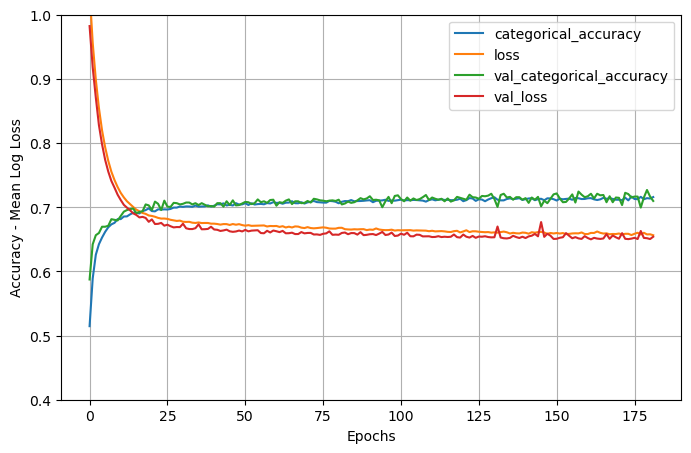

In [36]:
results=pd.DataFrame(history.history)
results.plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel ("Epochs")
plt.ylabel ("Accuracy - Mean Log Loss")
plt.gca().set_ylim(0.4, 1) # set the vertical range to [0.4,1]
plt.show()

In [37]:
results[-1:]

,categorical_accuracy,loss,val_categorical_accuracy,val_loss
181,0.715824,0.656351,0.709741,0.654044


Let's see how the model predicts on the development test set:

In [39]:
dev_predictions=model.predict(x_dev).round(2)
dev_predictions[:20]

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([[0.26, 0.35, 0.39],
       [1.  , 0.  , 0.  ],
       [0.48, 0.38, 0.13],
       [0.51, 0.42, 0.06],
       [0.43, 0.47, 0.1 ],
       [0.52, 0.44, 0.04],
       [0.94, 0.06, 0.  ],
       [0.03, 0.24, 0.73],
       [0.96, 0.04, 0.  ],
       [0.7 , 0.28, 0.01],
       [0.02, 0.27, 0.71],
       [0.14, 0.58, 0.27],
       [0.  , 0.03, 0.97],
       [0.04, 0.53, 0.43],
       [0.07, 0.56, 0.37],
       [0.01, 0.12, 0.87],
       [0.98, 0.02, 0.  ],
       [0.86, 0.13, 0.  ],
       [0.  , 0.11, 0.89],
       [0.64, 0.28, 0.08]], dtype=float32)

In [40]:
dev_rounded_predictions=np.round(dev_predictions)
indices = np.argmax(dev_predictions,1)
for row, index in zip(dev_rounded_predictions, indices): row[index]=1
dev_rounded_predictions[:20]

array([[0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.]], dtype=float32)

In [41]:
t_dev[:20] #target classes

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [42]:
dev_correct_predictions = np.equal(np.argmax(dev_rounded_predictions,1),np.argmax(t_dev,1))
print (dev_correct_predictions[:30])

[ True False  True False False False False  True  True  True  True False
 False  True  True  True  True  True  True  True False  True  True False
 False  True  True  True  True False]


In [43]:
from collections import Counter
Counter (dev_correct_predictions)

Counter({True: 1452, False: 591})

#### Confusion Matrix
The confusion matrix may also appear transposed, with predicted values in columns and actual (true) values in rows. Therefore, it is essential to consider the placement of predicted and actual values in the matrix.

In [45]:
dev_sparse_predictions = np.argmax (dev_predictions,axis=1)
dev_sparse_targets = np.argmax(t_dev, axis=1)
print('Confusion Matrix')
c_m=pd.DataFrame(confusion_matrix(dev_sparse_predictions,dev_sparse_targets),columns=['True_Cheap', 'True_Average', 'True_Expensive'])
c_m.insert(0,'Classes',['Pred_Cheap', 'Pred_Average', 'Pred_Expensive'])
c_m['Sum']=c_m.sum(axis=1, numeric_only=True)
c_m

Confusion Matrix


,Classes,True_Cheap,True_Average,True_Expensive,Sum
0,Pred_Cheap,537,184,29,750
1,Pred_Average,107,380,129,616
2,Pred_Expensive,10,132,535,677


#### Clasification metrics

**Precision** is the ratio of correctly predicted observations in a class to the total predicted observations for that class. The question that this metric answer is of all predictions that labeled as a species, how many actually belong to that class?

$Precision = \frac{TP}{TP+FP}$

**Recall** is the ratio of correctly predicted observations to the all observations in actual class. The question recall answers is: for all the observations that truly belong to a class, how many did the model label correctly? Recall usually refers to the positive class, also known as *sensitivity*, while the recall of the negative class is referred to as *specificity*.

Recall (sensitivity) $= \frac{TP}{TP+FN}$

Specificity $= \frac{TN}{TN+FP}$

**F1 score** is the weighted average of Precision and Recall. Therefore, this score takes both mistakes into account. Intuitively it is not as easy to understand as accuracy, but F1 is usually more useful than accuracy, especially if you have an uneven class distribution. Accuracy works best if precision and recall have similar cost. If the cost of false positives and false negatives are very different, it’s better to look at both precision and recall.

f1-score $= \frac{2(Recall * Precision)} {Recall + Precision}$

In [48]:
print('Classification Report')
classes = ['Cheap', 'Average', 'Expensive']
print(classification_report(dev_sparse_targets, dev_sparse_predictions, target_names=classes))

Classification Report
              precision    recall  f1-score   support

       Cheap       0.72      0.82      0.76       654
     Average       0.62      0.55      0.58       696
   Expensive       0.79      0.77      0.78       693

    accuracy                           0.71      2043
   macro avg       0.71      0.71      0.71      2043
weighted avg       0.71      0.71      0.71      2043

